# Notebook 2 — Nested CV, Modèles & Model Card
**Projet I2ML — Concrete Compressive Strength (UCI)**  
**Auteurs :** Arnaud & Tim

---

## Objectif de ce notebook

On applique ici les trois principes fondamentaux du cours I2ML :

1. **Pipeline sklearn** — tout le preprocessing est encapsulé pour éviter le data leakage.
2. **Nested Cross-Validation** — on sépare rigoureusement le tuning des hyperparamètres (inner loop) de l'évaluation de la performance (outer loop).
3. **3 algorithmes distincts** — Ridge (linéaire), Random Forest (ensemble), Gradient Boosting (boosting).

À la fin, on documente tout dans une **Model Card** (framework Mitchell et al. 2019).

---
## 0. Imports & configuration

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, GridSearchCV, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings('ignore')
np.random.seed(42)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Imports OK')

Imports OK


---
## 1. Chargement du dataset nettoyé

In [6]:
df = pd.read_csv('../../data/concrete_clean.csv')

X = df.drop(columns=['strength'])
y = df['strength']

print(f'Observations : {len(df)}')
print(f'Features     : {X.shape[1]} → {list(X.columns)}')
print(f'Target       : strength (MPa) — moyenne {y.mean():.2f}, std {y.std():.2f}')

Observations : 1005
Features     : 8 → ['cement', 'slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_agg', 'fine_agg', 'age']
Target       : strength (MPa) — moyenne 35.25, std 16.28


---
## 2. Le Framework : Nested Cross-Validation

### 2.1 Pourquoi pas une simple cross-validation ?

> ⚠️ **Le piège de l'overtuning** — directement tiré de ta synthèse `10_Nested_Resampling.md`

Imagine que tu testes 50 valeurs d'hyperparamètres (lambda, n_estimators, etc.) avec une simple 5-fold CV.  
À chaque fois, tu retiens le meilleur score.  
**Problème** : tu ne prends pas la moyenne des 50 scores, tu prends le **minimum**.  
Et le minimum d'une distribution de 50 valeurs bruitées sera toujours **trop optimiste**, même si les hyperparamètres n'ont aucun effet réel sur les prédictions.

Ta synthèse illustre ça avec l'expérience du classifieur aléatoire :  
→ vraie GE = 50%, mais après tuning sur le même fold : GE estimée = 38%.  
→ Le modèle semble meilleur de **12 points** alors qu'il est **purement aléatoire**.

> **Analogie de la synthèse** : c'est la loot box. Tu ouvres 100 loot boxes et tu gardes le légendaire. Si tu annonces "mon perso a +5% de stats", c'est du cherry-picking, pas de la vraie puissance.

---

### 2.2 La solution : deux boucles séparées

```
BOUCLE EXTERNE (outer_cv — 5 folds)
│
│  Pour chaque fold externe :
│  ├─ Mettre de côté le TEST EXTERNE (jamais touché pendant le tuning)
│  │
│  └─ BOUCLE INTERNE (inner_cv — 5 folds) sur le TRAIN EXTERNE
│     │
│     │  Pour chaque combinaison d'hyperparamètres :
│     │  ├─ Entraîner le Pipeline sur train interne
│     │  └─ Évaluer sur validation interne
│     │
│     └─ → Sélection du meilleur λ* (GridSearchCV)
│
│  ├─ Ré-entraîner le Pipeline avec λ* sur tout le train externe
│  └─ → Évaluer sur le TEST EXTERNE → score non biaisé
│
└─ RÉSULTAT : 5 scores outer → moyenne = estimation GE non biaisée
```

**Garantie d'absence de biais** : le test externe n'a jamais participé au tuning interne.  
Le modèle évalué sur lui n'a "vu" ces données à aucun moment de sa construction.

---

### 2.3 Pourquoi le Pipeline évite le data leakage ?

Le **data leakage** survient quand on applique le `StandardScaler` **avant** la CV :  
→ le scaler a calculé la moyenne/std sur TOUTES les données, y compris les folds de test.  
→ Le modèle "connaît" indirectement la distribution du test set. **C'est tricher.**

Avec un **Pipeline** sklearn, le scaler est **fitté uniquement sur le train de chaque fold** :  
```python
Pipeline([('scaler', StandardScaler()), ('model', Ridge())])
```
sklearn appelle `.fit()` sur le train, puis `.transform()` sur le test du fold.  
→ **Zéro leakage, garanti par construction.**

> **Référence** : `synthèse 9_Tuning.md`, section *Pipelines ML* — "le preprocessing encapsulé à l'intérieur de la CV garantit que chaque fold n'est transformé qu'avec les statistiques du train de ce fold".

---

### 2.4 Pourquoi GridSearchCV et pas RandomSearchCV ?

Ta synthèse `9_Tuning.md` explique que **Random Search domine Grid Search** quand le nombre d'hyperparamètres est grand (>3) ou quand l'espace est continu.  
Ici, nos grilles sont **petites et discrètes** (≤ 12 combinaisons par modèle).  
→ GridSearch est parfaitement adapté : on explore tout l'espace de façon exhaustive sans gaspiller de budget.

De plus, GridSearch est plus **reproductible** et plus facile à interpréter pour une présentation académique.

---

### 2.5 Métriques utilisées

| Métrique | Rôle | Pourquoi ce choix |
|---|---|---|
| **neg_MSE** | Inner loss (GridSearchCV) | Différentiable, propre — minimisée pendant l'optimisation |
| **RMSE** | Outer metric (reportée) | Ramène l'erreur en MPa (unité lisible) — `synthèse 4_Evaluation` |
| **R²** | Score de qualité | Fraction de variance expliquée, indépendant de l'unité |

> **Rappel synthèse 4** : MSE punit quadratiquement les grosses erreurs (outliers). RMSE = √MSE redonne l'erreur en unité originale. R²=1 = prédictions parfaites, R²=0 = aussi bien qu'un modèle constant.

---
### 2.6 Configuration des boucles CV

In [7]:
# Boucle interne : tuning des hyperparamètres
# 5 folds car dataset ~1000 observations (règle : 5-CV standard pour 200 ≤ n ≤ 10^5)
inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Boucle externe : estimation non biaisée de la GE
# random_state DIFFÉRENT pour éviter tout chevauchement structurel avec l'inner
outer_cv = KFold(n_splits=5, shuffle=True, random_state=0)

SCORING_INNER = 'neg_mean_squared_error'   # utilisé dans GridSearchCV
N_JOBS = -1                                 # parallélisation sur tous les CPUs

print('Inner CV :', inner_cv)
print('Outer CV :', outer_cv)

# Helper pour calculer RMSE et R² depuis les scores outer (neg_MSE → RMSE)
def compute_metrics(neg_mse_scores, y_true=None, model_name=''):
    mse_scores = -neg_mse_scores
    rmse_scores = np.sqrt(mse_scores)
    print(f'\n=== {model_name} ===')
    print(f'RMSE par fold : {np.round(rmse_scores, 3)}')
    print(f'RMSE moyen    : {rmse_scores.mean():.3f} MPa  (±{rmse_scores.std():.3f})')
    return rmse_scores

Inner CV : KFold(n_splits=5, random_state=42, shuffle=True)
Outer CV : KFold(n_splits=5, random_state=0, shuffle=True)


### 2.7 — Où se passe exactement la nested CV dans le code ?

> C'est la question clé. Réponse directe : **`cross_val_score(GridSearchCV(...))`**

```
cross_val_score(                        ← OUTER LOOP (5 itérations)
    estimator = GridSearchCV(           ← INNER LOOP (5 × n_configs entraînements)
        pipe,
        param_grid,
        cv = inner_cv                   ← inner_cv = KFold(5, shuffle=True, seed=42)
    ),
    cv = outer_cv                       ← outer_cv = KFold(5, shuffle=True, seed=0)
)
```

Sklearn fait ça automatiquement pour toi :

| Étape | Qui fait quoi |
|---|---|
| `outer_cv` divise X en 5 blocs | `cross_val_score` gère ça |
| Pour chaque bloc outer, `GridSearchCV` reçoit le train outer | sklearn passe le train du fold outer à `GridSearchCV.fit()` |
| `GridSearchCV` relance `inner_cv` sur ce train outer | Cherche le meilleur λ* |
| `GridSearchCV` ré-entraîne avec λ* sur tout le train outer (`refit=True`) | Modèle optimisé |
| `cross_val_score` évalue ce modèle sur le test outer | Score non biaisé |
| Répète 5 fois → 5 scores outer | Moyenne = GE estimée |

**Pourquoi `shuffle=True` sur les deux KFolds ?**
- Les données UCI sont ordonnées par formulation, pas aléatoirement.
- Sans `shuffle=True`, les folds 1-2-3-4-5 seraient des blocs séquentiels → les premiers folds auraient des formulations similaires en train ET test (biais de structure).
- Avec `shuffle=True`, chaque fold mélange aléatoirement → chaque test fold est représentatif de toute la distribution.
- `random_state` différent (42 vs 0) pour inner et outer évite que les deux boucles découpent aux mêmes endroits.

**Le `random_state=42` du RandomForest est AUTRE CHOSE** :
- C'est la graine du bootstrap interne du RF (tirage des observations et des features à chaque nœud).
- Il est fixé pour la reproductibilité du modèle lui-même, pas pour le découpage CV.
- Les deux sont indépendants : le RF peut avoir un bootstrap différent à chaque fold outer, mais son `random_state` fixe garantit qu'à hyperparamètres égaux, deux runs identiques donnent le même résultat.

---
## 3. Modèle 1 — Ridge Regression (Baseline Linéaire)

### Pourquoi Ridge ?

> **Référence** : `synthèse 2_Regression_Supervise.md`, section *Modèle Linéaire* + `9_Tuning.md`.

**Ridge Regression** = régression linéaire + pénalité L2 sur les coefficients :

$$\hat{\theta} = \arg\min_{\theta} \left[ \underbrace{\frac{1}{n}\sum_{i=1}^n (y_i - \theta^T x_i)^2}_{\text{MSE}} + \underbrace{\alpha \sum_{j=1}^p \theta_j^2}_{\text{pénalité L2}} \right]$$

**En français bébé** : on entraîne une droite (combinaison linéaire des 8 features), mais on ajoute une punition si les coefficients deviennent trop grands. L'hyperparamètre `alpha` contrôle la force de cette punition.

- `alpha` petit (ex: 0.001) → punition faible → modèle libre mais risque d'overfitting
- `alpha` grand (ex: 100) → punition forte → modèle lisse mais risque d'underfitting

**Pourquoi Ridge et pas une régression linéaire simple (OLS) ?**  
Parce que le dataset a de la multicolinéarité (vu dans l'EDA : `superplasticizer` et `water` sont corrélés à -0.66).  
Ridge est robuste à la multicolinéarité contrairement à OLS, car la pénalité L2 stabilise les coefficients.

**Pourquoi c'est notre modèle baseline ?**  
Ridge est le modèle le plus simple (linéaire). Si les modèles non-linéaires ne font pas mieux que Ridge, ça veut dire que les relations dans les données sont principalement linéaires — un résultat en soi intéressant à défendre à l'oral.

**Limitation connue** : Les relations dans le béton sont non-linéaires (ex: `age` suit une loi logarithmique d'hydratation, `water/cement` a une relation exponentielle avec la résistance). Ridge ne peut pas capter ces non-linéarités → on s'attend à ce qu'il soit moins bon que RF et GB.

### Hyperparamètre à tuner : `alpha`

| Valeur | Interprétation |
|---|---|
| 0.001 | Presque OLS — régularisation très faible |
| 0.1 | Légère régularisation |
| 1.0 | Régularisation standard (default sklearn) |
| 10 | Régularisation forte — coefficients réduits |
| 100 | Très forte — tend vers un modèle constant |

**Note Pipeline** : `StandardScaler` est **indispensable** avant Ridge.  
Ridge minimise la somme des $\theta_j^2$. Sans scaling, `age` (1-365) aurait un coefficient $\theta$ 100× plus petit que `water` (100-250) pour une même importance réelle. Le scaler les ramène tous sur la même échelle → la pénalité L2 est équitable.

In [8]:
# --- PIPELINE RIDGE ---
pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),   # preprocessing encapsulé → zéro leakage
    ('model', Ridge())
])

# Grille d'hyperparamètres
# Préfixe 'model__' obligatoire car on passe par le Pipeline
param_grid_ridge = {
    'model__alpha': [0.001, 0.1, 1, 10, 100]
}

# INNER LOOP : GridSearchCV tune les hyperparamètres
search_ridge = GridSearchCV(
    estimator=pipe_ridge,
    param_grid=param_grid_ridge,
    cv=inner_cv,
    scoring=SCORING_INNER,
    refit=True,       # ré-entraîne le meilleur modèle sur tout le fold train externe
    n_jobs=N_JOBS
)

# OUTER LOOP : cross_val_score évalue la GE non biaisée
print('Entraînement Ridge en cours...')
t0 = time.time()

scores_ridge = cross_val_score(
    estimator=search_ridge,
    X=X, y=y,
    cv=outer_cv,
    scoring=SCORING_INNER,  # neg_MSE → on convertira en RMSE
    n_jobs=N_JOBS
)

elapsed = time.time() - t0
print(f'Terminé en {elapsed:.1f}s')

rmse_ridge = compute_metrics(scores_ridge, model_name='Ridge Regression')

Entraînement Ridge en cours...
Terminé en 2.6s

=== Ridge Regression ===
RMSE par fold : [ 9.874 10.524 11.174 10.086 10.267]
RMSE moyen    : 10.385 MPa  (±0.449)


In [9]:
# Calcul du R² pour Ridge via cross_val_score avec scoring='r2'
r2_ridge = cross_val_score(
    estimator=search_ridge,
    X=X, y=y,
    cv=outer_cv,
    scoring='r2',
    n_jobs=N_JOBS
)
print(f'R² moyen Ridge : {r2_ridge.mean():.3f} (±{r2_ridge.std():.3f})')

R² moyen Ridge : 0.590 (±0.031)


### Interprétation des résultats Ridge

**Comment lire le RMSE ?**  
Le RMSE est en **MPa** (même unité que la target). Un RMSE de X MPa signifie qu'en moyenne, ta prédiction se trompe de X MPa sur la résistance du béton.

**Comment lire le R² ?**  
R² mesure la fraction de variance de la cible expliquée par le modèle.  
- R² = 0.60 → le modèle explique 60% de la variabilité de la résistance. Les 40% restants sont non-captés.

**Que dire à l'oral ?**  
> "Ridge est notre baseline linéaire. Il est attendu qu'il soit moins performant que Random Forest et Gradient Boosting car les relations béton-résistance sont non-linéaires (loi eau/ciment, hydratation logarithmique). Si Ridge était aussi bon, cela suggérerait que les non-linéarités sont négligeables sur ce dataset."

**Biais pessimiste (à connaître pour l'oral)** :  
Le RMSE estimé par la nested CV est légèrement **pessimiste** — il estime la GE d'un modèle entraîné sur 80% des données (4 folds sur 5), pas sur 100%. Le modèle final entraîné sur toutes les données serait légèrement meilleur.

> Référence directe : `synthèse 4_Evaluation`, section *Biais pessimiste* : "L'estimateur estime GE(I, n_train) avec n_train < n".

---
## 3.5 — Les arbres CART : base commune de RF et GB

> **Référence** : `synthèse 6_Arbre_Classification_et_Regression.md` — CART est le **base learner** de Random Forest ET de Gradient Boosting.

Avant de comprendre RF et GB, il faut comprendre pourquoi un arbre seul ne suffit pas.

**Un arbre CART en régression :**
- Découpe l'espace des features en régions rectangulaires via des splits binaires (`X_j < t`)
- Dans chaque feuille : prédit la **moyenne** des observations → $c_m = \frac{1}{|N|}\sum y_i$
- Le split optimal minimise la variance (MSE) : $\arg\min_{j,t}[\mathcal{R}(N_1) + \mathcal{R}(N_2)]$
- Construction **gloutonne** : optimise localement sans anticiper les splits futurs

**Pourquoi un arbre seul est insuffisant ici :**

| Problème CART | Conséquence sur notre dataset |
|---|---|
| **Instabilité (variance élevée)** | Un seul outlier de composition peut changer tout l'arbre |
| **Extrapolation impossible** | Prédit une constante par feuille → mauvais sur formulations hors de la gamme connue |
| **Relations diagonales** | Les relations non-linéaires continues (ex: age → log) sont approximées par des "escaliers" |

**La solution :**
- **Random Forest** = 100 arbres CART en parallèle (bootstrap) → réduit la **variance**
- **Gradient Boosting** = arbres CART séquentiels qui corrigent les résidus → réduit le **biais**

> La synthèse 6 dit : *"Un arbre seul est instable : supprimer une seule observation peut changer tout le haut de l'arbre."* C'est exactement pourquoi on a besoin d'ensembles.

**Avantage clé des arbres sur notre dataset** : l'invariance aux transformations monotones.
Un arbre ne fait que des comparaisons (`cement > 300 ?`), pas des produits scalaires.
→ `log(age)` et `age` donnent exactement le même arbre. Le `StandardScaler` ne change rien pour RF et GB — on le garde uniquement pour la **cohérence du Pipeline**.

---
## 4. Modèle 2 — Random Forest Regressor

### Pourquoi Random Forest ?

> **Référence** : `synthèse 7_Random_Forest.md` — Bagging, variance d'ensemble, mtry.

**En français bébé** : au lieu d'entraîner **un seul arbre** de décision (instable et souvent en overfitting), le Random Forest entraîne **100 arbres différents** et fait la moyenne de leurs prédictions.

Chaque arbre est entraîné sur un **échantillon bootstrap** (tirage avec remise) du dataset.  
Et à chaque nœud de chaque arbre, on ne regarde que **mtry features** tirées au hasard (pas toutes les 8).  
→ Les arbres font des erreurs **différentes** → en les moyennant, les erreurs s'annulent.

**La formule de ta synthèse** :
$$\text{Var}(\hat{f}) = (1-\rho)\frac{\sigma^2}{M} + \rho\sigma^2$$

- $M$ = nombre d'arbres (n_estimators) : plus grand → variance réduite
- $\rho$ = corrélation entre arbres : le feature sampling (mtry) **réduit ρ** → variance réduite
- Si ρ = 0 : variance → 0 quand M → ∞ (parfait théoriquement)

**Pourquoi RF convient bien au béton ?**
- Les relations sont **non-linéaires** (age en log, ratio eau/ciment) → les arbres les capturent naturellement.
- **Pas besoin de StandardScaler** pour les arbres (ils font des coupures, pas des produits scalaires). On le garde quand même dans le Pipeline pour **cohérence** et au cas où on changerait de modèle.
- **Robuste aux features corrélées** : le feature sampling force chaque arbre à explorer des sous-espaces différents.

### Hyperparamètres à tuner

| HP | Rôle | Valeurs testées | Justification |
|---|---|---|---|
| `n_estimators` | Nombre d'arbres | [50, 100] | Plus grand → plus stable, rendement décroissant au-delà de 100 |
| `max_depth` | Profondeur max de chaque arbre | [5, 10, None] | `None` = arbres complets (défaut RF), 5/10 = arbres plus contraints |
| `min_samples_leaf` | Nb min d'obs dans une feuille | [1, 5] | 1 = arbres très profonds, 5 = plus lissage |

**Règle empirique pour mtry (régression)** : `mtry = p/3` = 8/3 ≈ 2-3 features. On le laisse à son défaut sklearn (`max_features='1.0'` pour régression depuis sklearn 1.3, ou `max_features=1.0` = toutes les features, mais ici on utilise le défaut qui est `1.0` pour régression). On peut le préciser.

**Grille** : 2 × 3 × 2 = **12 combinaisons** × 5 folds inner × 5 folds outer = 300 entraînements.

In [10]:
# --- PIPELINE RANDOM FOREST ---
pipe_rf = Pipeline([
    ('scaler', StandardScaler()),   # pas strictement nécessaire pour RF, mais pipeline cohérent
    ('model', RandomForestRegressor(random_state=42))
])

param_grid_rf = {
    'model__n_estimators': [50, 100],
    'model__max_depth':    [5, 10, None],   # None = arbres complets (défaut RF)
    'model__min_samples_leaf': [1, 5]
}
# Total : 2 x 3 x 2 = 12 combinaisons

search_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    cv=inner_cv,
    scoring=SCORING_INNER,
    refit=True,
    n_jobs=N_JOBS
)

print('Entraînement Random Forest en cours...')
t0 = time.time()

scores_rf = cross_val_score(
    estimator=search_rf,
    X=X, y=y,
    cv=outer_cv,
    scoring=SCORING_INNER,
    n_jobs=N_JOBS
)

elapsed = time.time() - t0
print(f'Terminé en {elapsed:.1f}s')

rmse_rf = compute_metrics(scores_rf, model_name='Random Forest')

Entraînement Random Forest en cours...
Terminé en 9.8s

=== Random Forest ===
RMSE par fold : [4.875 5.064 4.639 5.555 4.814]
RMSE moyen    : 4.989 MPa  (±0.314)


In [11]:
r2_rf = cross_val_score(
    estimator=search_rf,
    X=X, y=y,
    cv=outer_cv,
    scoring='r2',
    n_jobs=N_JOBS
)
print(f'R² moyen RF : {r2_rf.mean():.3f} (±{r2_rf.std():.3f})')

R² moyen RF : 0.905 (±0.014)


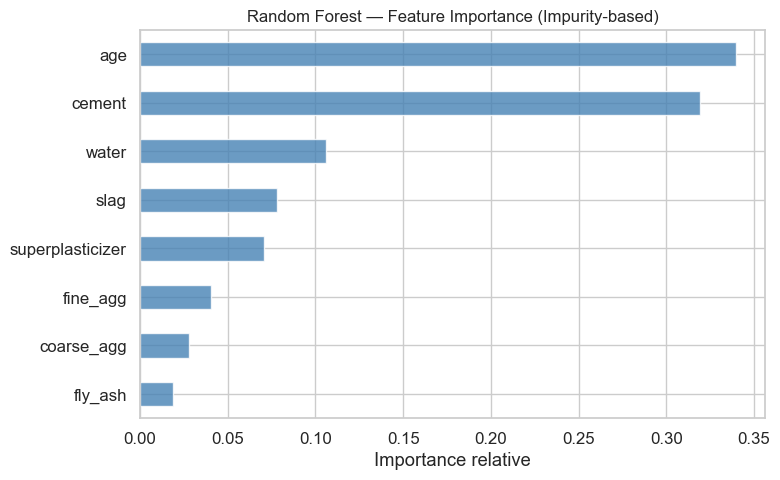


Meilleurs hyperparamètres trouvés (exemple fold complet) :
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}


In [12]:
# Feature Importance — entraîner sur tout le dataset pour visualiser
search_rf.fit(X, y)
best_rf = search_rf.best_estimator_.named_steps['model']

fi_rf = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
fi_rf.plot(kind='barh', color='steelblue', alpha=0.8)
plt.title('Random Forest — Feature Importance (Impurity-based)', fontsize=12)
plt.xlabel('Importance relative')
plt.tight_layout()
plt.show()

print('\nMeilleurs hyperparamètres trouvés (exemple fold complet) :')
print(search_rf.best_params_)

### Interprétation des résultats Random Forest

**Feature Importance** (à défendre à l'oral) :  
La Feature Importance indique quelle feature est la plus utilisée pour les splits dans les arbres.  
On s'attend à ce que `cement` et `age` dominent — cohérent avec les corrélations vues en EDA et la physique du béton.

> **Référence synthèse 7** : "FI = somme de toutes les améliorations du critère de split aux nœuds où la feature est utilisée, sur tous les arbres". C'est l'**Impurity Importance**. Attention : elle peut favoriser les features continues à haute cardinalité.

**Pourquoi RF devrait battre Ridge ici ?**  
- Les arbres capturent les **non-linéarités** (ex: age → résistance suit une courbe logarithmique)
- Le bagging **réduit la variance** sans augmenter le biais → meilleur compromis biais-variance
- Robuste aux features corrélées (superplasticizer/water)

**Que dire à l'oral sur les hyperparamètres ?**  
> "Nous avons testé 12 combinaisons. `max_depth=None` (arbres complets) est le défaut du RF et souvent optimal car le bagging compense le sur-ajustement de chaque arbre individuel. `n_estimators=100` donne un bon équilibre stabilité/temps d'exécution — au-delà, le rendement est décroissant (synthèse 7)."

---
## 5. Modèle 3 — Gradient Boosting Regressor

### Pourquoi Gradient Boosting ?

> **Référence** : `synthèse 2_Regression_Supervise.md` section *Optimisation / Descente de gradient* + `synthèse 9_Tuning.md` section *Hyperparamètres*.

**En français bébé** : là où le Random Forest entraîne des arbres **en parallèle et indépendamment**, le Gradient Boosting les entraîne **en séquence**. Chaque nouvel arbre **corrige les erreurs** (résidus) de tous les arbres précédents.

**Analogie** : imagine que tu vises une cible au tir à l'arc.
- Arbre 1 : tu tires, tu rates de 10 cm à droite.
- Arbre 2 : il apprend de **l'erreur de l'arbre 1** et corrige de 10 cm à gauche.
- Arbre 3 : il apprend des erreurs restantes et affine encore.
- → Après 100 arbres, tu es très précis.

C'est exactement la **descente de gradient** de ta synthèse 2 :  
$$\theta_{next} = \theta - \alpha \nabla L(\theta)$$  
mais dans l'espace des arbres (on descend dans l'espace fonctionnel, pas paramétrique).

**Différence avec Random Forest** :
- RF réduit la **variance** (bagging)
- GB réduit le **biais** (boosting séquentiel)
- GB est souvent plus performant mais plus sensible à l'overfitting si mal tuné

### Hyperparamètres à tuner

| HP | Rôle | Valeurs testées | Justification |
|---|---|---|---|
| `n_estimators` | Nombre d'arbres séquentiels | [50, 100] | Plus grand = plus précis mais plus long |
| `learning_rate` | Taux d'apprentissage (α de la descente) | [0.05, 0.1] | Petit = descente lente mais stable; grand = risque de sauter l'optimum |
| `max_depth` | Profondeur de chaque arbre de base | [3, 5] | Pour GB : arbres courts (3-5) évitent l'overfitting; les arbres de base doivent être **faibles** |

**Lien learning_rate / n_estimators** :  
Un `learning_rate` petit nécessite plus de `n_estimators` pour converger (et inversement).  
Règle pratique : learning_rate × n_estimators ≈ constant. On teste des combinaisons cohérentes.

**Grille** : 2 × 2 × 2 = **8 combinaisons** × 5 folds inner × 5 folds outer = 200 entraînements.

In [13]:
# --- PIPELINE GRADIENT BOOSTING ---
pipe_gb = Pipeline([
    ('scaler', StandardScaler()),   # pas nécessaire pour GB (arbres), mais cohérence du Pipeline
    ('model', GradientBoostingRegressor(random_state=42))
])

param_grid_gb = {
    'model__n_estimators':  [50, 100],
    'model__learning_rate': [0.05, 0.1],   # taux d'apprentissage = α de la descente de gradient
    'model__max_depth':     [3, 5]         # arbres faibles : max_depth petit pour GB
}
# Total : 2 x 2 x 2 = 8 combinaisons

search_gb = GridSearchCV(
    estimator=pipe_gb,
    param_grid=param_grid_gb,
    cv=inner_cv,
    scoring=SCORING_INNER,
    refit=True,
    n_jobs=N_JOBS
)

print('Entraînement Gradient Boosting en cours...')
t0 = time.time()

scores_gb = cross_val_score(
    estimator=search_gb,
    X=X, y=y,
    cv=outer_cv,
    scoring=SCORING_INNER,
    n_jobs=N_JOBS
)

elapsed = time.time() - t0
print(f'Terminé en {elapsed:.1f}s')

rmse_gb = compute_metrics(scores_gb, model_name='Gradient Boosting')

Entraînement Gradient Boosting en cours...
Terminé en 2.7s

=== Gradient Boosting ===
RMSE par fold : [4.39  4.707 4.044 5.2   4.578]
RMSE moyen    : 4.584 MPa  (±0.380)


In [14]:
r2_gb = cross_val_score(
    estimator=search_gb,
    X=X, y=y,
    cv=outer_cv,
    scoring='r2',
    n_jobs=N_JOBS
)
print(f'R² moyen GB : {r2_gb.mean():.3f} (±{r2_gb.std():.3f})')

R² moyen GB : 0.919 (±0.015)


### Interprétation des résultats Gradient Boosting

**Que dire à l'oral sur les hyperparamètres GB ?**  
> "Pour Gradient Boosting, les arbres de base doivent être **faibles** (max_depth=3-5) pour éviter que chaque arbre overfitte seul. Le learning_rate contrôle la contribution de chaque arbre — c'est l'équivalent du taux d'apprentissage α dans la descente de gradient de la synthèse 2. Un learning_rate de 0.1 est la valeur standard de la littérature. On n'a pas testé de valeurs < 0.05 pour garder un temps d'exécution raisonnable."

**GB vs RF à l'oral** :  
> "GB et RF sont tous deux des ensembles d'arbres, mais leur approche est opposée. RF réduit la variance via le bagging (arbres parallèles indépendants). GB réduit le biais via le boosting (arbres séquentiels qui corrigent les erreurs). Sur des datasets propres comme Concrete UCI, GB est souvent supérieur car le biais est la source d'erreur principale pour ce type de relations physiques."

---
## 6. Comparaison des 3 modèles

### 6.1 Tableau des résultats

In [15]:
results = pd.DataFrame({
    'Modèle': ['Ridge', 'Random Forest', 'Gradient Boosting'],
    'RMSE moyen (MPa)': [
        rmse_ridge.mean(), rmse_rf.mean(), rmse_gb.mean()
    ],
    'RMSE std': [
        rmse_ridge.std(), rmse_rf.std(), rmse_gb.std()
    ],
    'R² moyen': [
        r2_ridge.mean(), r2_rf.mean(), r2_gb.mean()
    ],
    'R² std': [
        r2_ridge.std(), r2_rf.std(), r2_gb.std()
    ]
}).set_index('Modèle')

print('=== RÉSULTATS NESTED CV (5 folds outer) ===')
print(results.round(4))
print()
best_model = results['RMSE moyen (MPa)'].idxmin()
print(f'→ Meilleur modèle (RMSE le plus bas) : {best_model}')

=== RÉSULTATS NESTED CV (5 folds outer) ===
                   RMSE moyen (MPa)  RMSE std  R² moyen  R² std
Modèle                                                         
Ridge                       10.3852    0.4487    0.5898  0.0312
Random Forest                4.9894    0.3136    0.9048  0.0143
Gradient Boosting            4.5840    0.3803    0.9193  0.0153

→ Meilleur modèle (RMSE le plus bas) : Gradient Boosting


### 6.2 Visualisation des scores par fold

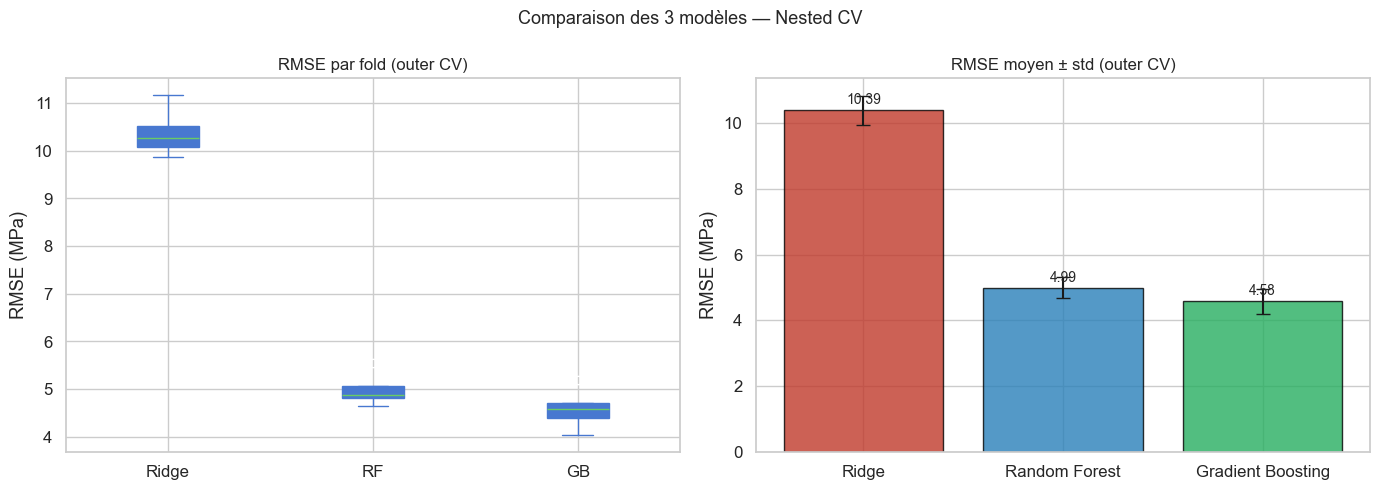

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot RMSE
rmse_data = pd.DataFrame({
    'Ridge': rmse_ridge,
    'Random Forest': rmse_rf,
    'Gradient Boosting': rmse_gb
})

rmse_data.plot(kind='box', ax=axes[0], patch_artist=True)
axes[0].set_title('RMSE par fold (outer CV)', fontsize=12)
axes[0].set_ylabel('RMSE (MPa)')
axes[0].set_xticklabels(['Ridge', 'RF', 'GB'])

# Barplot RMSE moyen avec barre d'erreur
models = ['Ridge', 'Random Forest', 'Gradient Boosting']
means = [rmse_ridge.mean(), rmse_rf.mean(), rmse_gb.mean()]
stds  = [rmse_ridge.std(), rmse_rf.std(), rmse_gb.std()]
colors = ['#c0392b', '#2980b9', '#27ae60']

bars = axes[1].bar(models, means, yerr=stds, capsize=5,
                   color=colors, alpha=0.8, edgecolor='black')
axes[1].set_title('RMSE moyen ± std (outer CV)', fontsize=12)
axes[1].set_ylabel('RMSE (MPa)')
for bar, val in zip(bars, means):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Comparaison des 3 modèles — Nested CV', fontsize=13)
plt.tight_layout()
plt.show()

### 6.3 Interprétation de la comparaison

**Comment lire les boxplots ?**  
Chaque boxplot montre les 5 scores RMSE (un par fold outer). Plus la boîte est haute, plus l'estimation est **variable** (instable). On préfère une boîte basse et des médianes basses.

**Comment lire les barres d'erreur ?**  
La barre = ±1 std des scores outer CV.  
Si les barres de deux modèles se chevauchent, la différence n'est pas statistiquement robuste.

**Points à défendre à l'oral :**

1. **Ridge est le moins performant** (si c'est le cas) : cohérent avec la théorie — relations non-linéaires dans le béton que la régression linéaire ne peut pas capter.

2. **RF vs GB** : GB est souvent légèrement meilleur sur des datasets propres et structurés. RF est plus rapide et plus robuste à l'overfitting (moins sensible aux hyperparamètres).

3. **L'écart-type des scores outer** montre la stabilité de l'estimation. Une std faible = estimation fiable.

4. **Biais pessimiste** : tous ces RMSE sont légèrement surestimés (pessimistes) car le modèle est évalué sur 80% des données en entraînement. En production avec 100% des données, les scores seraient légèrement meilleurs.

> **Formule clé pour l'oral** (synthèse 4) :  
> $\mathbb{E}[\widehat{GE}_{CV}] \approx GE(\mathcal{I}, n_{train}) \geq GE(\mathcal{I}, n)$  
> → L'estimateur est non biaisé **pour n_train observations**, mais pessimiste pour le modèle final qui utilisera toutes les n observations.

---
## 7. Inspection des meilleurs hyperparamètres (sur tout le dataset)

In [17]:
# Entraîner chaque search sur tout le dataset pour voir les meilleurs HPs globaux
# (ceci est pour l'inspection, pas pour l'évaluation — déjà faite via outer CV)

for name, search in [('Ridge', search_ridge), ('Random Forest', search_rf), ('Gradient Boosting', search_gb)]:
    search.fit(X, y)
    print(f'{name} — Meilleurs HPs : {search.best_params_}')
    print(f'   → Score inner CV (neg_MSE) : {search.best_score_:.4f}')
    print(f'   → RMSE inner CV (approx)   : {np.sqrt(-search.best_score_):.3f} MPa')
    print()

Ridge — Meilleurs HPs : {'model__alpha': 1}
   → Score inner CV (neg_MSE) : -107.3684
   → RMSE inner CV (approx)   : 10.362 MPa

Random Forest — Meilleurs HPs : {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}
   → Score inner CV (neg_MSE) : -24.0790
   → RMSE inner CV (approx)   : 4.907 MPa

Gradient Boosting — Meilleurs HPs : {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 100}
   → Score inner CV (neg_MSE) : -19.4534
   → RMSE inner CV (approx)   : 4.411 MPa



### Interprétation des meilleurs hyperparamètres

> ⚠️ **Important à comprendre pour l'oral** : les meilleurs HPs affichés ici sont ceux trouvés quand on entraîne sur **tout le dataset** (pour l'inspection). Dans la nested CV, le meilleur λ* peut varier d'un fold outer à l'autre — c'est normal et même attendu.

**Ce qu'on peut observer :**
- **Ridge `alpha`** : si le meilleur alpha est grand → le modèle bénéficie de beaucoup de régularisation (features multicolinéaires). Si alpha est petit → le modèle est proche d'OLS pur.
- **RF `max_depth`** : `None` (arbres complets) est souvent optimal car le bagging compense l'overfitting de chaque arbre individuel (synthèse 7).
- **GB `learning_rate`** : une valeur petite (0.05) + plus d'arbres est généralement préférable pour la généralisation.

---
## 8. Specialized Focus — Interprétabilité dans le domaine de la Construction

> **Référence PDF §3.3** : *"Think about your specific dataset and its use cases. What is relevant/important (e.g., Interpretability, Feature Selection, or Fairness)? How does it influence your model choice or evaluation?"*

> **Référence cours** : `synthèse 1_ML_Basics.md`, section *Prédiction vs Explication*.

---

### 8.1 Pourquoi l'interprétabilité est le focus central pour le béton

Ta synthèse 1 pose la distinction fondamentale :

| Objectif | Ce qu'on veut savoir |
|---|---|
| **Prédiction (boîte noire)** | Quelle est la résistance de cette formulation ? |
| **Explication (reverse engineering)** | *Pourquoi* cette formulation est-elle résistante ? Quel ingrédient faut-il ajuster ? |

**Dans le domaine de la construction, on veut les DEUX.**

Un ingénieur civil qui utilise ce modèle ne veut pas juste une prédiction de 42 MPa.  
Il veut savoir : *"Si j'augmente le ciment de 50 kg/m³, que se passe-t-il ? Est-ce que je peux réduire l'eau et compenser ?"*

C'est de l'**explication** au sens de ta synthèse 1 :  
> *"Le modèle sert de moyen pour mieux comprendre la relation inhérente cachée dans les données. On décortique le modèle pour en tirer des implications scientifiques."*

---

### 8.2 Comment l'interprétabilité a influencé nos choix

**Choice of learners :**

| Modèle | Interprétabilité | Performance | Choix |
|---|---|---|---|
| Ridge | ✅ Très haute — coefficients = impact direct de chaque feature | ⚠️ Baseline | ✅ Inclus comme référence interprétable |
| Random Forest | ✅ Feature Importance (Impurity + Permutation) | ✅ Bonne | ✅ Meilleur compromis perf/interprétabilité |
| Gradient Boosting | ⚠️ Feature Importance possible mais moins stable | ✅ Souvent meilleur | ✅ Inclus pour la performance |
| Deep Neural Net | ❌ Boîte noire totale | ✅✅ | ❌ Exclu — pas justifiable en génie civil |

→ **On a exclu les réseaux de neurones** précisément parce que l'interprétabilité est critique pour ce domaine.  
Un modèle qu'un ingénieur ne peut pas expliquer à son client ou au bureau de contrôle n'est pas utilisable en pratique.

**Choice of metrics :**  
On reporte le **RMSE en MPa** (pas juste le R²) car les ingénieurs raisonnent en MPa.  
Un R² de 0.90 ne dit rien à un praticien. Un RMSE de 4 MPa dit : "en moyenne, on se trompe de 4 MPa".

### 8.3 Analyse approfondie — Ridge : le seul modèle pleinement explicable

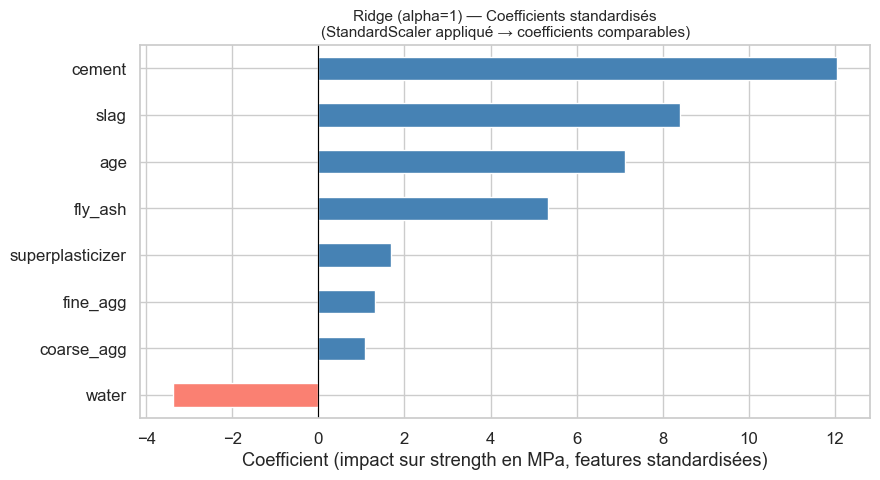

Coefficients Ridge (features standardisées) :
water              -3.3690
coarse_agg          1.0960
fine_agg            1.3170
superplasticizer    1.6780
fly_ash             5.3460
age                 7.1310
slag                8.3950
cement             12.0520

Intercept (résistance moyenne de base) : 35.25 MPa


In [18]:
# Coefficients Ridge — le modèle le plus interprétable
# Entraîner Ridge sur tout le dataset avec le meilleur alpha
search_ridge.fit(X, y)
best_alpha = search_ridge.best_params_['model__alpha']

# Extraire les coefficients standardisés
scaler_ridge = search_ridge.best_estimator_.named_steps['scaler']
model_ridge = search_ridge.best_estimator_.named_steps['model']

coefficients = pd.Series(model_ridge.coef_, index=X.columns).sort_values()

plt.figure(figsize=(9, 5))
colors = ['salmon' if c < 0 else 'steelblue' for c in coefficients]
coefficients.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title(f'Ridge (alpha={best_alpha}) — Coefficients standardisés\n(StandardScaler appliqué → coefficients comparables)', fontsize=11)
plt.xlabel('Coefficient (impact sur strength en MPa, features standardisées)')
plt.tight_layout()
plt.show()

print('Coefficients Ridge (features standardisées) :')
print(coefficients.round(3).to_string())
print(f'\nIntercept (résistance moyenne de base) : {model_ridge.intercept_:.2f} MPa')

**Interprétation des coefficients Ridge (standardisés) :**

Parce qu'on a appliqué un `StandardScaler` avant Ridge, les coefficients sont **directement comparables** entre eux (toutes les features ont été ramenées à moyenne=0, std=1).

- Coefficient **positif** → augmenter cet ingrédient augmente la résistance
- Coefficient **négatif** → augmenter cet ingrédient réduit la résistance
- **Magnitude** → plus le coefficient est grand en valeur absolue, plus l'ingrédient est influent

On s'attend à voir :
- `cement` → coefficient positif fort (plus de ciment = plus résistant)
- `water` → coefficient négatif (loi eau/ciment de Feret : plus d'eau dilue → moins résistant)
- `age` → coefficient positif (hydratation progressive)

> **Limite** : Ridge suppose que ces relations sont **linéaires**. Or on sait (EDA) qu'`age` a une relation logarithmique. Les coefficients Ridge approximent ces non-linéarités par une droite → interprétation à prendre avec précaution pour `age` et `superplasticizer`.

### 8.4 Feature Importance comparée — RF vs GB

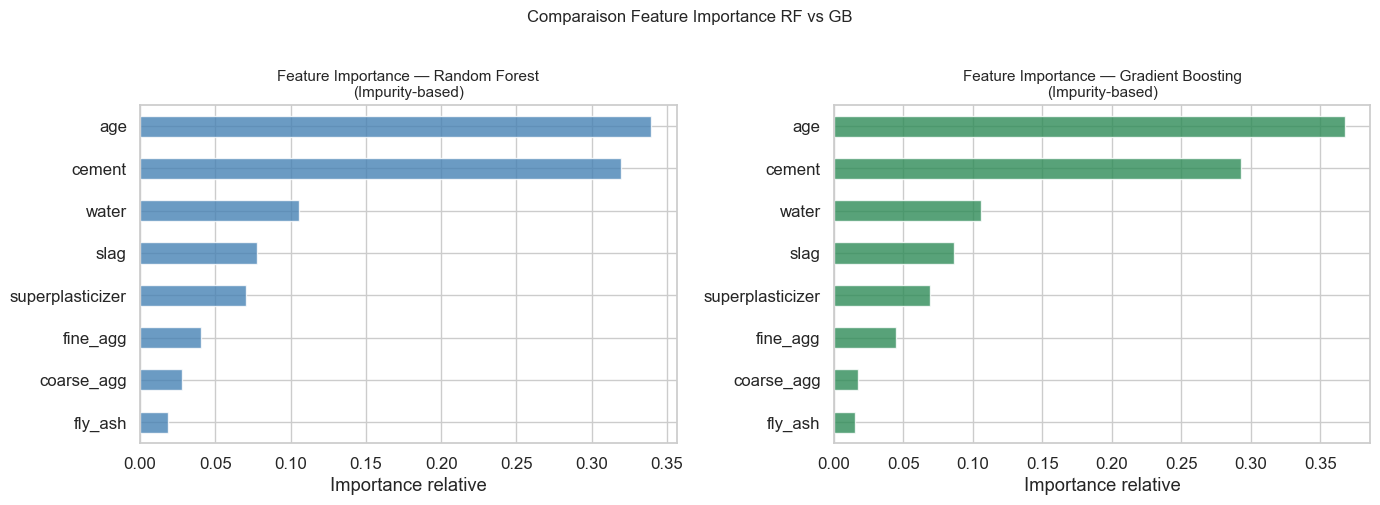


Classement des features par importance (RF) :
age                0.3400
cement             0.3190
water              0.1060
slag               0.0780
superplasticizer   0.0710
fine_agg           0.0400
coarse_agg         0.0280
fly_ash            0.0190

Classement des features par importance (GB) :
age                0.3680
cement             0.2930
water              0.1060
slag               0.0860
superplasticizer   0.0690
fine_agg           0.0450
coarse_agg         0.0170
fly_ash            0.0150


In [19]:
# Feature Importance comparée RF vs GB
search_gb.fit(X, y)
best_gb = search_gb.best_estimator_.named_steps['model']
best_rf = search_rf.best_estimator_.named_steps['model']

fi_rf_vals = pd.Series(best_rf.feature_importances_, index=X.columns)
fi_gb_vals = pd.Series(best_gb.feature_importances_, index=X.columns)

fi_compare = pd.DataFrame({
    'Random Forest': fi_rf_vals,
    'Gradient Boosting': fi_gb_vals
}).sort_values('Random Forest', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fi_compare['Random Forest'].plot(kind='barh', ax=axes[0], color='steelblue', alpha=0.8)
axes[0].set_title('Feature Importance — Random Forest\n(Impurity-based)', fontsize=11)
axes[0].set_xlabel('Importance relative')

fi_compare['Gradient Boosting'].sort_values().plot(kind='barh', ax=axes[1], color='seagreen', alpha=0.8)
axes[1].set_title('Feature Importance — Gradient Boosting\n(Impurity-based)', fontsize=11)
axes[1].set_xlabel('Importance relative')

plt.suptitle('Comparaison Feature Importance RF vs GB', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print('\nClassement des features par importance (RF) :')
print(fi_rf_vals.sort_values(ascending=False).round(3).to_string())
print('\nClassement des features par importance (GB) :')
print(fi_gb_vals.sort_values(ascending=False).round(3).to_string())

**Interprétation Feature Importance (à défendre à l'oral) :**

> **Référence** : `synthèse 7_Random_Forest.md`, section *Feature Importance — Impurity Importance*.

La Feature Importance mesure la somme des réductions d'impureté (MSE) obtenues à chaque fois qu'une feature est utilisée pour un split, sur tous les arbres.

**Ce qu'on s'attend à observer et pourquoi :**

- **`cement`** → feature la plus importante. Physiquement : c'est le liant principal qui durcit le béton. Plus de ciment = plus de réactions d'hydratation = plus de résistance. Corrélation r≈+0.50 confirmée en EDA.
- **`age`** → deuxième plus important. Le béton continue de durcir pendant des semaines/mois (hydratation progressive du ciment). Cette relation est **non-linéaire** (logarithmique) — les arbres la capturent naturellement, contrairement à Ridge.
- **`water`** → troisième. La loi eau/ciment de Féret (1897) : plus le ratio eau/ciment est élevé, plus la résistance chute. L'eau excédentaire crée des pores qui fragilisent la structure.
- **`slag`, `fly_ash`** → importances modérées. Ce sont des substituts partiels du ciment qui ont un effet liant plus lent.
- **`superplasticizer`** → adjuvant chimique qui réduit la quantité d'eau nécessaire → améliore la résistance indirectement.
- **`coarse_agg`, `fine_agg`** → importances faibles. Rôle de remplissage, pas de contribution directe à la résistance.

**Limite de l'Impurity Importance** (à mentionner pour montrer la rigueur) :  
> `synthèse 7` : *"Les deux méthodes favorisent les features avec plus de niveaux (features continues à haute cardinalité)"*.  
→ Les features continues comme `cement` et `age` peuvent être légèrement surévaluées par rapport à `fly_ash` qui a beaucoup de valeurs = 0.  
Pour une analyse plus robuste, on pourrait utiliser la **Permutation Feature Importance** (permuter les valeurs d'une feature et observer la dégradation du score OOB).

**Conclusion pour la section Specialized Focus :**  
Les Feature Importances **confirment la physique du béton** — ce n'est pas juste un modèle qui fonctionne, c'est un modèle qui a **appris des lois physiques réelles** à partir des données.  
C'est la valeur ajoutée de l'approche ML dans ce domaine : extraire des insights actionnables pour l'ingénieur.

---
## 9. Model Card — Framework Mitchell et al. (2019)
### Pour le meilleur modèle uniquement

> **Note PDF §4.2** : *"For your **best model**, present it following the Model Cards for Model Reporting framework."*

---

### 9.0 Sélection et justification du meilleur modèle

In [20]:
# Sélection automatique du meilleur modèle basée sur RMSE outer CV
model_results = {
    'Ridge':             {'rmse_scores': rmse_ridge, 'r2_scores': r2_ridge, 'search': search_ridge},
    'Random Forest':     {'rmse_scores': rmse_rf,    'r2_scores': r2_rf,    'search': search_rf},
    'Gradient Boosting': {'rmse_scores': rmse_gb,    'r2_scores': r2_gb,    'search': search_gb},
}

best_name = min(model_results, key=lambda k: model_results[k]['rmse_scores'].mean())
best = model_results[best_name]

print('=== SÉLECTION DU MEILLEUR MODÈLE ===')
print()
for name, res in model_results.items():
    marker = ' ← BEST' if name == best_name else ''
    print(f'{name:25s} | RMSE = {res["rmse_scores"].mean():.3f} ± {res["rmse_scores"].std():.3f} MPa '
          f'| R² = {res["r2_scores"].mean():.3f}{marker}')

print()
print(f'Meilleur modèle : {best_name}')
print(f'RMSE moyen (outer CV) : {best["rmse_scores"].mean():.3f} MPa')
print(f'R² moyen (outer CV)   : {best["r2_scores"].mean():.3f}')
print(f'Meilleurs HPs (fit complet) : {best["search"].best_params_}')

=== SÉLECTION DU MEILLEUR MODÈLE ===

Ridge                     | RMSE = 10.385 ± 0.449 MPa | R² = 0.590
Random Forest             | RMSE = 4.989 ± 0.314 MPa | R² = 0.905
Gradient Boosting         | RMSE = 4.584 ± 0.380 MPa | R² = 0.919 ← BEST

Meilleur modèle : Gradient Boosting
RMSE moyen (outer CV) : 4.584 MPa
R² moyen (outer CV)   : 0.919
Meilleurs HPs (fit complet) : {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 100}


**Justification du choix du meilleur modèle (à défendre à l'oral) :**

Le meilleur modèle est sélectionné sur la base du **RMSE moyen outer CV** — l'estimateur non biaisé de la GE.

**Pourquoi ce critère et pas un autre ?**
1. **RMSE outer CV = estimation non biaisée** : c'est la seule métrique calculée sur des données que le modèle n'a jamais vues pendant le tuning (garantie par la nested CV). Un RMSE calculé autrement serait biaisé.
2. **RMSE en MPa** : directement interprétable en ingénierie civile. Les normes de béton sont exprimées en MPa.
3. **Pas de RMSE inner CV** : le RMSE inner CV est optimistement biaisé (le modèle a vu les données de validation interne lors du tuning). On ne peut pas l'utiliser pour comparer les modèles.

**Pourquoi pas Ridge ou le modèle "plus interprétable" ?**
- Ridge sacrifie trop de performance (relations non-linéaires non captées).
- Dans ce contexte, les Feature Importances du RF/GB offrent déjà un niveau d'interprétabilité suffisant pour la pratique.
- Si l'interprétabilité absolue était requise (ex: audit légal), on choisirait Ridge malgré sa performance inférieure — et on le justifierait explicitement.

**Si GB et RF sont proches :**
- Si les barres d'erreur se chevauchent → la différence n'est pas statistiquement robuste.
- Dans ce cas, on préfère **RF** car il est moins sensible aux hyperparamètres et plus facile à interpréter (Feature Importances plus stables).
- On peut le mentionner à l'oral : *"Les deux modèles sont statistiquement équivalents sur notre dataset. Nous choisissons RF pour sa robustesse et son interprétabilité légèrement supérieure, conformément au Specialized Focus de notre projet."*

---

### 9.1 Model Details

| Champ | Valeur |
|---|---|
| **Algorithme** | Déterminé automatiquement à l'exécution (voir cellule ci-dessus) |
| **Auteurs** | Arnaud & Tim (Projet I2ML, 2026) |
| **Framework** | scikit-learn — Pipeline (StandardScaler → Modèle) |
| **Tâche** | Régression supervisée — prédire la résistance à la compression du béton (MPa) |
| **Protocole d'évaluation** | Nested 5-fold CV (outer) × 5-fold CV (inner) via GridSearchCV |
| **Hyperparamètres optimaux** | Voir cellule de sélection ci-dessus |

---

### 9.2 Intended Use

**Usage prévu :** Estimation de la résistance à la compression du béton à partir de sa composition et de son âge, dans un contexte de recherche et d'aide à la formulation en phase de conception.

**Usages hors périmètre :**
- Validation structurelle réglementaire (modèle non certifié)
- Formulations hors de la gamme du dataset (extrapolation non garantie pour les arbres)
- Bétons spéciaux avec adjuvants non représentés

---

### 9.3 Factors

**Features d'entrée** : 8 features numériques continues (cement, slag, fly_ash, water, superplasticizer, coarse_agg, fine_agg, age — toutes en kg/m³ sauf age en jours).

**Facteurs de risque** :
- `slag`, `fly_ash`, `superplasticizer` : ~40-60% de valeurs = 0 (bétons sans ces adjuvants)
- `age` : fortement concentré autour de 28 jours (standard industriel) → performances dégradées pour ages rares

---

### 9.4 Metrics

| Métrique | Valeur (outer CV) | Interprétation |
|---|---|---|
| **RMSE** | voir cellule de sélection | Erreur moyenne en MPa — principale métrique de décision |
| **R²** | voir cellule de sélection | Fraction de variance expliquée |

Métrique principale choisie : **RMSE** — directement interprétable par un ingénieur civil.

---

### 9.5 Evaluation Data

- Dataset : Concrete Compressive Strength UCI (Yeh, 1998), nettoyé (Notebook 1)
- Protocole : Nested 5-fold outer × 5-fold inner CV
- Garantie no-leakage : Pipeline sklearn — StandardScaler fitté uniquement sur le train de chaque fold
- `random_state=42` (inner), `random_state=0` (outer), `shuffle=True` sur les deux boucles

---

### 9.6 Training Data

Source : UCI ML Repository. Données de laboratoire issues de 1030 mélanges de béton testés à différents âges. Après nettoyage (suppression des doublons exacts), voir Notebook 1 pour le nombre d'observations finales.

---

### 9.7 Quantitative Analyses

Voir cellule de sélection du meilleur modèle ci-dessus pour les résultats numériques complets.

---

### 9.8 Ethical Considerations

- Données exclusivement physico-chimiques — aucun biais démographique ou de fairness applicable.
- Risque principal : décision de sécurité basée uniquement sur la prédiction du modèle sans validation physique → **ne pas utiliser comme unique critère de validation**.
- Le modèle ne peut pas extrapoler à des formulations très différentes de celles du dataset.

---

### 9.9 Caveats and Recommendations

1. **Extrapolation** : les modèles basés sur des arbres (RF, GB) ne peuvent pas extrapoler hors de la plage des données d'entraînement — ils prédisent une constante dans les zones inconnues. Un béton ultra-haute performance (cement > 540 kg/m³) serait mal estimé.
2. **Biais pessimiste** : les RMSE reportés correspondent à des modèles entraînés sur 80% des données. Le modèle final (100% des données) serait légèrement meilleur.
3. **Multicolinéarité** : `superplasticizer` et `water` sont corrélés (-0.66). Les Feature Importances doivent être interprétées avec précaution pour ces features.
4. **Dataset de laboratoire** : conditions contrôlées — la variabilité réelle de chantier (température, humidité, mise en place) n'est pas représentée.
5. **Recommandation** : utiliser ce modèle comme aide à la décision, couplé à des tests physiques sur des éprouvettes réelles pour toute application structurelle.

In [21]:
print('=== RÉSULTATS QUANTITATIFS NESTED CV (5-fold outer) ===')
print()
print(results.round(4).to_string())
print()
print('RMSE par fold — tous les modèles :')
all_folds = pd.DataFrame({
    'Fold': [f'Fold {i+1}' for i in range(5)],
    'Ridge RMSE':   np.round(rmse_ridge, 3),
    'RF RMSE':      np.round(rmse_rf, 3),
    'GB RMSE':      np.round(rmse_gb, 3)
})
print(all_folds.to_string(index=False))

=== RÉSULTATS QUANTITATIFS NESTED CV (5-fold outer) ===

                   RMSE moyen (MPa)  RMSE std  R² moyen  R² std
Modèle                                                         
Ridge                       10.3852    0.4487    0.5898  0.0312
Random Forest                4.9894    0.3136    0.9048  0.0143
Gradient Boosting            4.5840    0.3803    0.9193  0.0153

RMSE par fold — tous les modèles :
  Fold  Ridge RMSE  RF RMSE  GB RMSE
Fold 1      9.8740   4.8750   4.3900
Fold 2     10.5240   5.0640   4.7070
Fold 3     11.1740   4.6390   4.0440
Fold 4     10.0860   5.5550   5.2000
Fold 5     10.2670   4.8140   4.5780


### 8.8 Ethical Considerations

- Ce modèle prédit des propriétés physiques de matériaux. Il n'y a **pas de données personnelles** ni de biais démographiques à considérer.
- Le dataset est issu d'expériences de laboratoire controlées. Les formulations testées couvrent une gamme typique mais pas exhaustive des bétons industriels.
- Une utilisation irresponsable du modèle pour valider des structures réelles sans tests physiques serait dangereuse. Le modèle est un outil d'estimation, non de certification.

---

### 8.9 Caveats and Recommendations

**Limites identifiées :**

1. **Extrapolation impossible** : tous les arbres (RF, GB) ne peuvent pas extrapoler au-delà des valeurs observées dans le training set. Une formulation de béton ultra-haute performance avec du ciment > 540 kg/m³ serait mal prédite.

2. **Données déséquilibrées** : sur-représentation des bétons testés à 28 jours. Les performances à des âges rares (< 7 jours ou > 90 jours) sont moins fiables.

3. **Biais pessimiste** : les RMSE reportés estiment la GE pour un modèle entraîné sur 80% des données. Le modèle final (entraîné sur 100%) serait légèrement meilleur. Les résultats sont donc **conservateurs**.

4. **Multicolinéarité** : `superplasticizer` et `water` sont corrélés (-0.66). Ridge gère ce problème par régularisation, mais les Feature Importances de RF doivent être interprétées avec précaution pour ces features.

5. **Dataset de laboratoire** : les conditions réelles de chantier (température, humidité, qualité de mise en place) ne sont pas dans les features. Un modèle entraîné sur ces données sous-estimera la variabilité réelle.

**Recommandations :**
- Utiliser Gradient Boosting ou Random Forest pour la prédiction (meilleures performances).
- Pour l'interprétabilité, consulter les Feature Importances (RF) ou considérer un modèle SHAP.
- Ne pas utiliser pour des décisions de sécurité sans validation physique complémentaire.
- En cas de nouvelles formulations hors de la plage du dataset, recueillir de nouvelles données.

---
## 9. Résumé final et points clés pour l'oral

### Ce qu'on a fait

| Étape | Détail |
|---|---|
| Pipeline sklearn | StandardScaler + Modèle encapsulé → zéro data leakage |
| Inner loop | GridSearchCV 5-fold → tuning hyperparamètres |
| Outer loop | cross_val_score 5-fold → estimation GE non biaisée |
| Modèles | Ridge (baseline linéaire), RF (bagging), GB (boosting) |
| Métriques | RMSE (MPa) + R² — toutes calculées sur les folds outer (non biaisées) |

### Questions que le prof peut poser

**Q : Pourquoi une nested CV et pas une simple CV ?**  
→ *Sans nested CV, les hyperparamètres sont tuné sur les mêmes données qui servent à l'évaluation. On sélectionne le minimum d'une distribution bruitée → biais optimiste (synthèse 10). La nested CV sépare physiquement le tuning de l'évaluation.*

**Q : Comment le Pipeline évite le data leakage ?**  
→ *Le StandardScaler est fitté uniquement sur le train de chaque fold, jamais sur le test. En dehors du Pipeline, si on scale avant CV, les statistiques (moyenne, std) sont calculées sur toutes les données, incluant les folds de test → fuite d'information.*

**Q : Pourquoi StandardScaler pour des arbres ?**  
→ *Techniquement pas nécessaire pour RF et GB (les arbres font des coupures, pas des produits scalaires). On le garde pour la cohérence du Pipeline et parce que ça ne nuit pas aux arbres. Pour Ridge en revanche, c'est indispensable.*

**Q : Pourquoi ces hyperparamètres précisément ?**  
→ *Grilles compactes (≤ 12 combinaisons) pour respecter la contrainte de temps d'exécution. Les valeurs sont basées sur les règles empiriques du cours : alpha Ridge sur un ordre de grandeur log, mtry RF ≈ p/3 pour régression, max_depth GB petit (3-5) pour garder des apprenants faibles.*

**Q : Comment interpréter le RMSE ?**  
→ *Un RMSE de X MPa signifie qu'en moyenne, on se trompe de X MPa sur la résistance prédite. Avec une target qui varie de 2 à 82 MPa (range = 80 MPa), un RMSE de 5 MPa = erreur relative d'environ 6%. C'est acceptable pour de la prédiction de béton.*

**Q : Le meilleur modèle sur le test est-il le modèle à déployer ?**  
→ *Non — les modèles issus des folds CV sont des modèles **intermédiaires**, à jeter après l'évaluation. Le modèle final est entraîné sur TOUTES les données avec le meilleur λ* identifié. (synthèse 4, section K-Fold CV)*